# Notebook 04 — Spatial Join, Distance and Meteorological Station Matching
## Spatial Relationships for Environmental Monitoring

**ระดับผู้เรียน:** ปริญญาตรีปี 3–4 / ปริญญาโท  
**กลุ่มสาขา:** สิ่งแวดล้อม ภูมิศาสตร์ ภูมิสารสนเทศ อุตุนิยมวิทยา  
**Platform:** Google Colab

---

# คำถามหลักของบทนี้

Notebook 03 ทำให้เราเข้าใจ:

```text
Point
Polygon
Longitude / Latitude
CRS
EPSG:4326
UTM 47N
```

Notebook 04 จะเริ่มตอบคำถามเชิงพื้นที่จริง:

```text
PCD station อยู่ในจังหวัดใด?
              ↓
Spatial Join

PCD station อยู่ในอำเภอ/ตำบลใด?
              ↓
Point-in-Polygon

PCD station อยู่ใกล้ WMO station ใด?
              ↓
Distance + Nearest Neighbor

ใกล้ที่สุด = เป็นตัวแทนดีที่สุดหรือไม่?
              ↓
Environmental Interpretation
```

---

# Workflow

```text
PCD Points
    +
Province / Amphoe / Tambon
    ↓
Spatial Join
    ↓
Administrative attributes

PCD Points
    +
WMO / OGIMET Points
    ↓
Projected CRS
    ↓
Nearest distance
    ↓
Geodesic validation
    ↓
Top-3 candidates
    ↓
Station-pair table
    ↓
PM2.5 daily observations
```

# Learning Outcomes

เมื่อจบ Notebook นี้ นิสิตควรสามารถ:

1. อธิบาย spatial join ได้
2. แยก attribute join กับ spatial join ได้
3. ใช้ `gpd.sjoin()` ทำ point-in-polygon ได้
4. ตรวจว่า PCD station อยู่จังหวัด อำเภอ และตำบลใด
5. เปรียบเทียบ geometry-derived attributes กับ canonical attributes
6. เข้าใจ boundary case ของ `within` และ `intersects`
7. อธิบายว่าทำไม distance ต้องใช้ CRS ที่เหมาะสม
8. ใช้ EPSG:32647 สำหรับ metric analysis ในกรณีศึกษา
9. ใช้ `gpd.sjoin_nearest()` หา WMO station ที่ใกล้ที่สุด
10. คำนวณ distance เป็น km
11. ตรวจ projected distance ด้วย geodesic distance
12. คำนวณ azimuth/bearing ระหว่างสถานี
13. สร้าง top-3 candidate meteorological stations
14. สร้างเส้นเชื่อมระหว่าง PCD และ WMO stations
15. วิเคราะห์ network coverage จาก nearest-station distance
16. เข้าใจว่า nearest ≠ representative
17. หา nearest WMO station ระดับประเทศไทยด้วย geodesic distance
18. เชื่อม station-pair metadata กลับเข้ากับ PM₂.₅ daily
19. แยก “station matching” ออกจาก “meteorological data merging”
20. สร้าง output ที่ใช้ต่อใน Notebook 05

# 4.1 Attribute Join vs Spatial Join

## Attribute Join

Notebook 02 ใช้:

```python
pd.merge(
    pollution,
    station_metadata,
    on="station_id"
)
```

เพราะทั้งสองตารางมี key เดียวกัน:

```text
station_id
```

---

## Spatial Join

แต่ถ้าเรามี:

```text
PCD station point
```

และ:

```text
Province polygon
```

Point ไม่มีความจำเป็นต้องมีชื่อจังหวัดอยู่ก่อน

เราสามารถถามจาก geometry ว่า:

> Point นี้อยู่ “ภายใน” Polygon ใด?

ด้วย:

```python
gpd.sjoin()
```

แนวคิด:

```text
Point + Polygon
      ↓
Spatial relationship
      ↓
New attributes
```

# 4.2 Spatial Predicates

คำที่ใช้บ่อย:

```text
within
contains
intersects
touches
overlaps
```

สำหรับคำถาม:

> สถานีอยู่ในจังหวัดใด?

เรามักใช้:

```text
Point within Polygon
```

แต่มีกรณีพิเศษ:

```text
Point อยู่พอดีบนขอบเขต Polygon
```

จุดนั้นอาจ:

```text
within = False
intersects = True
```

ดังนั้น spatial join ต้องมี QC ไม่ใช่เพียงสั่งคำสั่งแล้วเชื่อผลทันที

In [1]:
# CELL 1 — Install packages

!pip -q install -U \
    geopandas \
    pyogrio \
    shapely \
    pyproj \
    pandas \
    pyarrow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 15.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.5 which is incompatible.


In [2]:
# CELL 2 — Mount Google Drive

from google.colab import drive

drive.mount(
    "/content/drive",
    force_remount=False
)

Mounted at /content/drive


In [3]:
# CELL 3 — Imports

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import LineString
from pyproj import Geod

warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning
)

print("pandas   :", pd.__version__)
print("GeoPandas:", gpd.__version__)

pandas   : 3.0.5
GeoPandas: 1.1.4


# 4.3 Input Data

ใช้เฉพาะ course dataset ที่เตรียมไว้แล้ว

จาก Notebook 01:

```text
environmental_gis_course.gpkg
```

จาก Notebook 02:

```text
02_pcd_pm25_daily_2021_2025.csv.gz
```

จาก Notebook 03:

```text
03_case_study_layers.gpkg
```

Notebook 04 สามารถทำงานจาก canonical GeoPackage ได้แม้ไม่มีไฟล์ Notebook 03
แต่จะตรวจว่ามี output จาก Notebook 03 หรือไม่เพื่อใช้เป็น reference

In [4]:
# CELL 4 — Paths

DATASET_VERSION = "v1"

BASE_DIR = Path(
    "/content/drive/MyDrive/"
    "Teaching_PCD_Environmental_GIS"
)

DATASET_DIR = (
    BASE_DIR
    / "01_course_data"
    / DATASET_VERSION
    / "dataset"
)

NOTEBOOK02_OUTPUT = (
    BASE_DIR
    / "02_output"
    / "Notebook_02"
)

NOTEBOOK03_OUTPUT = (
    BASE_DIR
    / "02_output"
    / "Notebook_03"
)

OUTPUT_DIR = (
    BASE_DIR
    / "02_output"
    / "Notebook_04"
)

FIGURE_DIR = (
    BASE_DIR
    / "03_figures"
    / "Notebook_04"
)

for folder in [
    OUTPUT_DIR,
    FIGURE_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )

print("Dataset:")
print(DATASET_DIR)

print("\nNotebook 04 output:")
print(OUTPUT_DIR)

Dataset:
/content/drive/MyDrive/Teaching_PCD_Environmental_GIS/01_course_data/v1/dataset

Notebook 04 output:
/content/drive/MyDrive/Teaching_PCD_Environmental_GIS/02_output/Notebook_04


In [5]:
# CELL 5 — Locate files

def find_unique_file(
    root,
    filename,
    required=True,
):
    root = Path(
        root
    )

    if not root.exists():

        if required:

            raise FileNotFoundError(
                f"Folder not found: {root}"
            )

        return None

    matches = list(
        root.rglob(
            filename
        )
    )

    if len(
        matches
    ) == 1:

        return matches[
            0
        ]

    if len(
        matches
    ) == 0:

        if required:

            raise FileNotFoundError(
                f"Required file not found: {filename}"
            )

        return None

    raise RuntimeError(
        f"Multiple files found for {filename}: "
        + str(
            matches
        )
    )


COURSE_GPKG = find_unique_file(
    DATASET_DIR,
    "environmental_gis_course.gpkg",
)

PM25_DAILY_FILE = find_unique_file(
    NOTEBOOK02_OUTPUT,
    "02_pcd_pm25_daily_2021_2025.csv.gz",
    required=False,
)

CASE_GPKG_FROM_03 = find_unique_file(
    NOTEBOOK03_OUTPUT,
    "03_case_study_layers.gpkg",
    required=False,
)


print("Course GeoPackage:")
print(COURSE_GPKG)

print("\nNotebook 02 PM2.5:")
print(PM25_DAILY_FILE)

print("\nNotebook 03 case GeoPackage:")
print(CASE_GPKG_FROM_03)

Course GeoPackage:
/content/drive/MyDrive/Teaching_PCD_Environmental_GIS/01_course_data/v1/dataset/processed/environmental_gis_course.gpkg

Notebook 02 PM2.5:
/content/drive/MyDrive/Teaching_PCD_Environmental_GIS/02_output/Notebook_02/02_pcd_pm25_daily_2021_2025.csv.gz

Notebook 03 case GeoPackage:
/content/drive/MyDrive/Teaching_PCD_Environmental_GIS/02_output/Notebook_03/03_case_study_layers.gpkg


In [6]:
# CELL 6 — Read canonical layers

province = gpd.read_file(
    COURSE_GPKG,
    layer="province",
)

amphoe = gpd.read_file(
    COURSE_GPKG,
    layer="amphoe",
)

tambon = gpd.read_file(
    COURSE_GPKG,
    layer="tambon",
)

pcd = gpd.read_file(
    COURSE_GPKG,
    layer="pcd_stations",
)

ogimet = gpd.read_file(
    COURSE_GPKG,
    layer="ogimet_stations",
)


print(
    "Province:",
    len(
        province
    )
)

print(
    "Amphoe:",
    len(
        amphoe
    )
)

print(
    "Tambon:",
    len(
        tambon
    )
)

print(
    "PCD stations:",
    len(
        pcd
    )
)

print(
    "OGIMET/WMO stations:",
    len(
        ogimet
    )
)

Province: 77
Amphoe: 928
Tambon: 7425
PCD stations: 173
OGIMET/WMO stations: 130


In [7]:
# CELL 7 — Normalize station IDs

if (
    "station_id"
    not in pcd.columns
):

    raise KeyError(
        "PCD layer is missing station_id."
    )


if (
    "wmo_id"
    not in ogimet.columns
):

    raise KeyError(
        "OGIMET layer is missing wmo_id."
    )


pcd[
    "station_id"
] = (
    pcd[
        "station_id"
    ]
    .astype(
        "string"
    )
    .str.strip()
    .str.lower()
)


ogimet[
    "wmo_id"
] = (
    ogimet[
        "wmo_id"
    ]
    .astype(
        "string"
    )
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True,
    )
)


print(
    "Unique PCD IDs:",
    pcd[
        "station_id"
    ].nunique()
)

print(
    "Unique WMO IDs:",
    ogimet[
        "wmo_id"
    ].nunique()
)

Unique PCD IDs: 173
Unique WMO IDs: 130


In [8]:
# CELL 8 — CRS and geometry checkpoint

layer_checkpoint = pd.DataFrame([
    {
        "layer":
            "province",
        "rows":
            len(
                province
            ),
        "crs":
            str(
                province.crs
            ),
        "invalid_geometry_n":
            int(
                (
                    ~province.geometry.is_valid
                )
                .fillna(
                    True
                )
                .sum()
            ),
    },
    {
        "layer":
            "amphoe",
        "rows":
            len(
                amphoe
            ),
        "crs":
            str(
                amphoe.crs
            ),
        "invalid_geometry_n":
            int(
                (
                    ~amphoe.geometry.is_valid
                )
                .fillna(
                    True
                )
                .sum()
            ),
    },
    {
        "layer":
            "tambon",
        "rows":
            len(
                tambon
            ),
        "crs":
            str(
                tambon.crs
            ),
        "invalid_geometry_n":
            int(
                (
                    ~tambon.geometry.is_valid
                )
                .fillna(
                    True
                )
                .sum()
            ),
    },
    {
        "layer":
            "pcd",
        "rows":
            len(
                pcd
            ),
        "crs":
            str(
                pcd.crs
            ),
        "invalid_geometry_n":
            int(
                (
                    ~pcd.geometry.is_valid
                )
                .fillna(
                    True
                )
                .sum()
            ),
    },
    {
        "layer":
            "ogimet",
        "rows":
            len(
                ogimet
            ),
        "crs":
            str(
                ogimet.crs
            ),
        "invalid_geometry_n":
            int(
                (
                    ~ogimet.geometry.is_valid
                )
                .fillna(
                    True
                )
                .sum()
            ),
    },
])


display(
    layer_checkpoint
)

,layer,rows,crs,invalid_geometry_n
0,province,77,EPSG:4326,0
1,amphoe,928,EPSG:4326,0
2,tambon,7425,EPSG:4326,0
3,pcd,173,EPSG:4326,0
4,ogimet,130,EPSG:4326,0


# 4.4 Spatial Join: PCD Point → Province Polygon

เราจะสร้าง province attribute ใหม่จาก geometry

เพื่อแยกจาก attribute ที่เตรียมไว้เดิม ใช้ prefix:

```text
sj_
```

เช่น:

```text
sj_province_code
sj_province_name_en
```

ดังนั้นเราสามารถเปรียบเทียบ:

```text
canonical attribute
vs
spatial-join result
```

ได้โดยไม่เขียนทับข้อมูลเดิม

In [9]:
# CELL 9 — Helper for point-in-polygon spatial join

def point_in_polygon_join(
    points,
    polygons,
    fields,
    prefix,
):
    """
    Spatially join points to polygons using 'within'.

    Returns:
    - joined GeoDataFrame
    - QC dictionary

    Boundary points that are not strictly within a polygon
    remain unmatched and are reported for inspection.
    """

    right_fields = [
        field
        for field
        in fields
        if field
        in polygons.columns
    ]

    right = polygons[
        right_fields
        + [
            "geometry"
        ]
    ].copy()


    rename_map = {
        field:
            f"{prefix}_{field}"
        for field
        in right_fields
    }

    right = right.rename(
        columns=rename_map
    )


    joined = gpd.sjoin(
        points,
        right,
        how="left",
        predicate="within",
    )


    duplicate_station_rows = 0

    if (
        "station_id"
        in joined.columns
    ):

        duplicate_station_rows = int(
            joined[
                "station_id"
            ]
            .duplicated(
                keep=False
            )
            .sum()
        )


    joined = joined.drop(
        columns=[
            "index_right"
        ],
        errors="ignore",
    )


    first_result_field = (
        list(
            rename_map.values()
        )[
            0
        ]
        if rename_map
        else None
    )


    unmatched_n = (
        int(
            joined[
                first_result_field
            ]
            .isna()
            .sum()
        )
        if (
            first_result_field
            is not None
        )
        else np.nan
    )


    qc = {
        "prefix":
            prefix,

        "point_n":
            len(
                points
            ),

        "result_rows":
            len(
                joined
            ),

        "unmatched_n":
            unmatched_n,

        "duplicate_station_rows":
            duplicate_station_rows,
    }


    return (
        joined,
        qc,
    )

In [10]:
# CELL 10 — Spatial join: province

province_fields = [
    "province_code",
    "province_name_en",
    "province_name_th",
]


pcd_sj_province, qc_province = (
    point_in_polygon_join(
        points=pcd,
        polygons=province,
        fields=province_fields,
        prefix="sj",
    )
)


display(
    pd.DataFrame([
        qc_province
    ])
)


display(
    pcd_sj_province[
        [
            c
            for c
            in [
                "station_id",
                "province_name_en",
                "sj_province_name_en",
                "geometry",
            ]
            if c
            in pcd_sj_province.columns
        ]
    ].head(
        10
    )
)

,prefix,point_n,result_rows,unmatched_n,duplicate_station_rows
0,sj,173,173,0,0


,station_id,province_name_en,sj_province_name_en,geometry
0,119t,Krabi,Krabi,POINT (98.91805 8.05062)
1,02t,Bangkok,Bangkok,POINT (100.48766 13.73285)
2,03t,Bangkok,Bangkok,POINT (100.41426 13.63651)
3,05t,Bangkok,Bangkok,POINT (100.60574 13.66618)
4,12t,Bangkok,Bangkok,POINT (100.54733 13.70807)
5,50t,Bangkok,Bangkok,POINT (100.5365 13.72985)
6,52t,Bangkok,Bangkok,POINT (100.48657 13.72762)
7,53t,Bangkok,Bangkok,POINT (100.59303 13.79542)
8,54t,Bangkok,Bangkok,POINT (100.5502 13.76252)
9,59t,Bangkok,Bangkok,POINT (100.54049 13.78318)


# 4.5 Spatial Join ต่อไปยัง Amphoe และ Tambon

แนวคิดเหมือนกัน:

```text
PCD Point
   ↓ within
Amphoe Polygon
   ↓
amphoe attribute
```

และ:

```text
PCD Point
   ↓ within
Tambon Polygon
   ↓
tambon attribute
```

ในงานสิ่งแวดล้อม spatial join ใช้บ่อยมาก เช่น:

```text
monitoring station → district
sampling point → watershed
fire hotspot → protected area
health case → administrative unit
```

In [11]:
# CELL 11 — Spatial join: amphoe

amphoe_fields = [
    "amphoe_code",
    "amphoe_name_en",
    "amphoe_name_th",
]


pcd_sj_amphoe, qc_amphoe = (
    point_in_polygon_join(
        points=pcd,
        polygons=amphoe,
        fields=amphoe_fields,
        prefix="sj",
    )
)


display(
    pd.DataFrame([
        qc_amphoe
    ])
)

,prefix,point_n,result_rows,unmatched_n,duplicate_station_rows
0,sj,173,173,0,0


In [12]:
# CELL 12 — Spatial join: tambon

tambon_fields = [
    "tambon_code",
    "tambon_name_en",
    "tambon_name_th",
]


pcd_sj_tambon, qc_tambon = (
    point_in_polygon_join(
        points=pcd,
        polygons=tambon,
        fields=tambon_fields,
        prefix="sj",
    )
)


display(
    pd.DataFrame([
        qc_tambon
    ])
)

,prefix,point_n,result_rows,unmatched_n,duplicate_station_rows
0,sj,173,173,0,0


In [13]:
# CELL 13 — Build one geometry-derived administrative station table

province_sj_fields = [
    c
    for c
    in [
        "station_id",
        "sj_province_code",
        "sj_province_name_en",
        "sj_province_name_th",
    ]
    if c
    in pcd_sj_province.columns
]


amphoe_sj_fields = [
    c
    for c
    in [
        "station_id",
        "sj_amphoe_code",
        "sj_amphoe_name_en",
        "sj_amphoe_name_th",
    ]
    if c
    in pcd_sj_amphoe.columns
]


tambon_sj_fields = [
    c
    for c
    in [
        "station_id",
        "sj_tambon_code",
        "sj_tambon_name_en",
        "sj_tambon_name_th",
    ]
    if c
    in pcd_sj_tambon.columns
]


pcd_admin_from_geometry = (
    pcd[
        [
            c
            for c
            in [
                "station_id",
                "station_name_th",
                "station_name_en",
                "latitude",
                "longitude",
                "province_name_en",
                "amphoe_name_en",
                "tambon_name_en",
                "geometry",
            ]
            if c
            in pcd.columns
        ]
    ]
    .copy()
)


pcd_admin_from_geometry = (
    pcd_admin_from_geometry
    .merge(
        pcd_sj_province[
            province_sj_fields
        ],
        on="station_id",
        how="left",
        validate="one_to_one",
    )
)


pcd_admin_from_geometry = (
    pcd_admin_from_geometry
    .merge(
        pcd_sj_amphoe[
            amphoe_sj_fields
        ],
        on="station_id",
        how="left",
        validate="one_to_one",
    )
)


pcd_admin_from_geometry = (
    pcd_admin_from_geometry
    .merge(
        pcd_sj_tambon[
            tambon_sj_fields
        ],
        on="station_id",
        how="left",
        validate="one_to_one",
    )
)


pcd_admin_from_geometry = gpd.GeoDataFrame(
    pcd_admin_from_geometry,
    geometry="geometry",
    crs=pcd.crs,
)


display(
    pcd_admin_from_geometry.head(
        10
    )
)

,station_id,station_name_th,station_name_en,latitude,longitude,province_name_en,amphoe_name_en,tambon_name_en,geometry,sj_province_code,sj_province_name_en,sj_province_name_th,sj_amphoe_code,sj_amphoe_name_en,sj_amphoe_name_th,sj_tambon_code,sj_tambon_name_en,sj_tambon_name_th
0,119t,สวนสาธารณะธารา,Thara Public Park,8.050624,98.918049,Krabi,Mueang Krabi,Sai Thai,POINT (98.91805 8.05062),<NA>,Krabi,กระบี่,TH8101,Mueang Krabi,เมืองกระบี่,TH810115,Sai Thai,à¹à¸ªà¹à¸à¸¢
1,02t,มหาวิทยาลัยราชภัฏบ้านสมเด็จเจ้าพระยา,Bansomdejchaopraya Rajabhat University,13.732846,100.487662,Bangkok,Thon Buri,Hiranruchi,POINT (100.48766 13.73285),<NA>,Bangkok,กรุงเทพมหานคร,TH1015,Thon Buri,ธนบุรี,TH101502,Hiranruchi,à¸«à¸´à¸£à¸±à¸à¸£à¸¹à¸à¸µ
2,03t,ริมถนนทางหลวงหมายเลข 3902,Highway NO.3902 km.13 +600,13.636514,100.414262,Bangkok,Bang Khun Thian,Samae Dam,POINT (100.41426 13.63651),<NA>,Bangkok,กรุงเทพมหานคร,TH1021,Bang Khun Thian,บางขุนเทียน,TH102107,Samae Dam,à¹à¸ªà¸¡à¸à¸³
3,05t,กรมอุตุนิยมวิทยาบางนา,Thai Meteorological Department,13.666183,100.605742,Bangkok,Bang Na,Bang Na,POINT (100.60574 13.66618),<NA>,Bangkok,กรุงเทพมหานคร,TH1047,Bang Na,บางนา,TH104701,Bang Na,à¸à¸²à¸à¸à¸²
4,12t,โรงเรียนนนทรีวิทยา,Nonsi Witthaya School,13.708067,100.547333,Bangkok,Yan Nawa,Chong Nonsi,POINT (100.54733 13.70807),<NA>,Bangkok,กรุงเทพมหานคร,TH1012,Yan Nawa,ยานนาวา,TH101203,Chong Nonsi,à¸à¹à¸­à¸à¸à¸à¸à¸£à¸µ
5,50t,โรงพยาบาลจุฬาลงกรณ์,Chulalongkorn Hospital,13.729852,100.536501,Bangkok,Pathum Wan,Pathum Wan,POINT (100.5365 13.72985),<NA>,Bangkok,กรุงเทพมหานคร,TH1007,Pathum Wan,ปทุมวัน,TH100703,Pathum Wan,à¸à¸à¸¸à¸¡à¸§à¸±à¸
6,52t,การไฟฟ้าย่อยธนบุรี,Thonburi Power Sub-Station,13.727622,100.486568,Bangkok,Thon Buri,Hiranruchi,POINT (100.48657 13.72762),<NA>,Bangkok,กรุงเทพมหานคร,TH1015,Thon Buri,ธนบุรี,TH101502,Hiranruchi,à¸«à¸´à¸£à¸±à¸à¸£à¸¹à¸à¸µ
7,53t,สถานีตำรวจนครบาลโชคชัย,Chokchai Police Station,13.795425,100.593030,Bangkok,Wang Thonglang,Saphan Song,POINT (100.59303 13.79542),<NA>,Bangkok,กรุงเทพมหานคร,TH1045,Wang Thonglang,วังทองหลาง,TH104502,Saphan Song,à¸ªà¸°à¸à¸²à¸à¸ªà¸­à¸
8,54t,การเคหะชุมชนดินแดง,National Housing Authority Dindaeng,13.762517,100.550200,Bangkok,Din Daeng,Din Daeng,POINT (100.5502 13.76252),<NA>,Bangkok,กรุงเทพมหานคร,TH1026,Din Daeng,ดินแดง,TH102601,Din Daeng,à¸à¸´à¸à¹à¸à¸
9,59t,กรมประชาสัมพันธ์,The Government Public Relations Department,13.783185,100.540489,Bangkok,Phaya Thai,Sam Sen Nai,POINT (100.54049 13.78318),<NA>,Bangkok,กรุงเทพมหานคร,TH1014,Phaya Thai,พญาไท,TH101401,Sam Sen Nai,à¸ªà¸²à¸¡à¹à¸ªà¸à¹à¸


# 4.6 Geometry-derived Attributes vs Existing Metadata

Canonical dataset มี administrative attributes อยู่แล้วจาก Notebook 00

Notebook 04 จะตรวจว่า:

```text
existing province
=
province from spatial join ?
```

ถ้าไม่ตรง ต้องตรวจ:

- point coordinate
- boundary source
- administrative version
- name normalization
- geometry validity
- station metadata

ไม่ควรเลือกค่าหนึ่งโดยอัตโนมัติแล้วทิ้งอีกค่า

In [14]:
# CELL 14 — Compare administrative attributes

def normalized_text(
    series,
):
    return (
        series.astype(
            "string"
        )
        .str.strip()
        .str.lower()
        .str.replace(
            r"\s+",
            " ",
            regex=True,
        )
    )


comparison_fields = [
    (
        "province_name_en",
        "sj_province_name_en",
        "province_match",
    ),
    (
        "amphoe_name_en",
        "sj_amphoe_name_en",
        "amphoe_match",
    ),
    (
        "tambon_name_en",
        "sj_tambon_name_en",
        "tambon_match",
    ),
]


for original_field, spatial_field, output_field in comparison_fields:

    if (
        original_field
        in pcd_admin_from_geometry.columns
        and spatial_field
        in pcd_admin_from_geometry.columns
    ):

        original = normalized_text(
            pcd_admin_from_geometry[
                original_field
            ]
        )

        spatial = normalized_text(
            pcd_admin_from_geometry[
                spatial_field
            ]
        )

        pcd_admin_from_geometry[
            output_field
        ] = (
            (
                original
                == spatial
            )
            |
            (
                original.isna()
                & spatial.isna()
            )
        )

In [15]:
# CELL 15 — Administrative join validation report

admin_validation_rows = []

for level in [
    "province",
    "amphoe",
    "tambon",
]:

    match_field = (
        f"{level}_match"
    )

    spatial_name_field = (
        f"sj_{level}_name_en"
    )

    if (
        match_field
        in pcd_admin_from_geometry.columns
    ):

        admin_validation_rows.append({
            "level":
                level,

            "station_n":
                len(
                    pcd_admin_from_geometry
                ),

            "spatially_matched_n":
                int(
                    pcd_admin_from_geometry[
                        spatial_name_field
                    ]
                    .notna()
                    .sum()
                ),

            "attribute_agreement_n":
                int(
                    pcd_admin_from_geometry[
                        match_field
                    ]
                    .sum()
                ),

            "attribute_mismatch_n":
                int(
                    (
                        ~pcd_admin_from_geometry[
                            match_field
                        ]
                    )
                    .sum()
                ),
        })


admin_validation = pd.DataFrame(
    admin_validation_rows
)


display(
    admin_validation
)

,level,station_n,spatially_matched_n,attribute_agreement_n,attribute_mismatch_n
0,province,173,173,173,0
1,amphoe,173,173,173,0
2,tambon,173,173,173,0


In [16]:
# CELL 16 — Inspect administrative mismatches

mismatch_columns = [
    c
    for c
    in [
        "station_id",
        "station_name_en",
        "latitude",
        "longitude",
        "province_name_en",
        "sj_province_name_en",
        "amphoe_name_en",
        "sj_amphoe_name_en",
        "tambon_name_en",
        "sj_tambon_name_en",
    ]
    if c
    in pcd_admin_from_geometry.columns
]


mismatch_mask = pd.Series(
    False,
    index=pcd_admin_from_geometry.index,
)


for match_field in [
    "province_match",
    "amphoe_match",
    "tambon_match",
]:

    if (
        match_field
        in pcd_admin_from_geometry.columns
    ):

        mismatch_mask = (
            mismatch_mask
            |
            (
                ~pcd_admin_from_geometry[
                    match_field
                ]
            )
        )


admin_mismatches = (
    pcd_admin_from_geometry[
        mismatch_mask
    ][
        mismatch_columns
    ]
    .copy()
)


print(
    "Stations requiring administrative review:",
    len(
        admin_mismatches
    )
)


display(
    admin_mismatches.head(
        30
    )
)

Stations requiring administrative review: 0


,station_id,station_name_en,latitude,longitude,province_name_en,sj_province_name_en,amphoe_name_en,sj_amphoe_name_en,tambon_name_en,sj_tambon_name_en


# Boundary Case

ถ้า Point อยู่บนเส้นขอบ:

```text
within = False
```

อาจตรวจเพิ่มด้วย:

```python
gpd.sjoin(
    points,
    polygons,
    predicate="intersects"
)
```

แต่ถ้า point อยู่บนขอบร่วมของ 2 polygons:

```text
intersects
```

อาจให้ 2 matches

ดังนั้น boundary case ต้อง **review**
ไม่ควรเลือก polygon แรกแบบเงียบ ๆ

# 4.7 เลือกกรณีศึกษา 3 จังหวัดจากผล Spatial Join

ใช้:

```text
Saraburi
Lop Buri
Nakhon Nayok
```

คราวนี้จะเลือกจาก:

```text
sj_province_name_en
```

ซึ่งสร้างจาก geometry โดยตรง

In [17]:
# CELL 17 — Robust case-province name normalization

CASE_PROVINCES_NORMALIZED = {
    "saraburi":
        "Saraburi",

    "lop buri":
        "Lop Buri",

    "lopburi":
        "Lop Buri",

    "nakhon nayok":
        "Nakhon Nayok",

    "nakhonnayok":
        "Nakhon Nayok",
}


def normalize_place_name(
    value,
):
    if pd.isna(
        value
    ):
        return None

    value = (
        str(
            value
        )
        .strip()
        .lower()
    )

    value = " ".join(
        value.split()
    )

    return value


pcd_admin_from_geometry[
    "sj_province_normalized"
] = (
    pcd_admin_from_geometry[
        "sj_province_name_en"
    ]
    .map(
        normalize_place_name
    )
)


case_station_mask = (
    pcd_admin_from_geometry[
        "sj_province_normalized"
    ]
    .isin(
        CASE_PROVINCES_NORMALIZED.keys()
    )
)


case_pcd = (
    pcd_admin_from_geometry[
        case_station_mask
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


print(
    "Case-study PCD stations:",
    len(
        case_pcd
    )
)


display(
    case_pcd[
        [
            c
            for c
            in [
                "station_id",
                "station_name_en",
                "sj_province_name_en",
                "sj_amphoe_name_en",
                "sj_tambon_name_en",
                "latitude",
                "longitude",
            ]
            if c
            in case_pcd.columns
        ]
    ]
)

Case-study PCD stations: 4


,station_id,station_name_en,sj_province_name_en,sj_amphoe_name_en,sj_tambon_name_en,latitude,longitude
0,105t,Nakhon Nayok Municipality Public Health Servic...,Nakhon Nayok,Mueang Nakhon Nayok,Nakhon Nayok,14.204220,101.215090
1,99t,Meteorological Station Lopburi,Lop Buri,Mueang Lop Buri,Thale Chup Son,14.800032,100.628548
2,24t,Na Phralan Police Station,Saraburi,Chaloem Phra Kiat,Na Phralan,14.685833,100.871996
3,25t,Khao Noi Fire Station,Saraburi,Mueang Saraburi,Pak Phriao,14.526343,100.926047


In [18]:
# CELL 18 — Select case-study province polygons

province[
    "_name_norm"
] = (
    province[
        "province_name_en"
    ]
    .map(
        normalize_place_name
    )
)


case_provinces = (
    province[
        province[
            "_name_norm"
        ]
        .isin(
            CASE_PROVINCES_NORMALIZED.keys()
        )
    ]
    .copy()
)


print(
    "Case province polygons:",
    len(
        case_provinces
    )
)

Case province polygons: 3


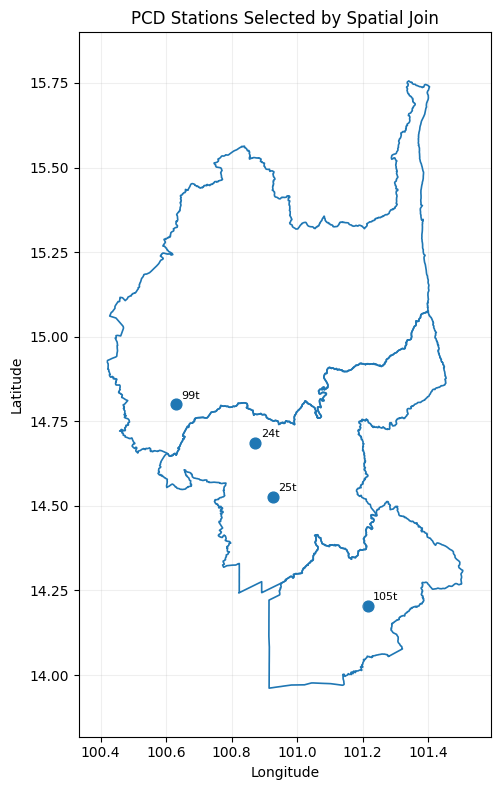

In [19]:
# CELL 19 — Plot geometry-derived station locations

fig, ax = plt.subplots(
    figsize=(
        9,
        8,
    )
)

case_provinces.boundary.plot(
    ax=ax,
    linewidth=1.2,
)

case_pcd.plot(
    ax=ax,
    markersize=60,
)


for _, row in case_pcd.iterrows():

    ax.annotate(
        str(
            row[
                "station_id"
            ]
        ),
        xy=(
            row.geometry.x,
            row.geometry.y,
        ),
        xytext=(
            4,
            4,
        ),
        textcoords="offset points",
        fontsize=8,
    )


xmin, ymin, xmax, ymax = (
    case_provinces.total_bounds
)


xpad = (
    xmax
    - xmin
) * 0.08

ypad = (
    ymax
    - ymin
) * 0.08


ax.set_xlim(
    xmin - xpad,
    xmax + xpad,
)

ax.set_ylim(
    ymin - ypad,
    ymax + ypad,
)

ax.set_xlabel(
    "Longitude"
)

ax.set_ylabel(
    "Latitude"
)

ax.set_title(
    "PCD Stations Selected by Spatial Join"
)

ax.grid(
    alpha=0.2
)

fig.tight_layout()

SPATIAL_JOIN_MAP = (
    FIGURE_DIR
    / "04_case_PCD_spatial_join.png"
)

fig.savefig(
    SPATIAL_JOIN_MAP,
    dpi=250,
    bbox_inches="tight",
)

plt.show()

# 4.8 Distance Requires an Appropriate CRS

กรณีศึกษานี้อยู่ประมาณ:

```text
100–101°E
14–15°N
```

เราจะใช้:

```text
WGS 84 / UTM zone 47N
EPSG:32647
```

สำหรับ metric distance

---

## ทำไมไม่ใช้ EPSG:4326?

เพราะ:

```text
EPSG:4326 → degree
```

แต่เราต้องการ:

```text
distance_m
distance_km
```

ดังนั้น:

```text
EPSG:4326
    ↓ to_crs()
EPSG:32647
    ↓
distance in metres
```

# 4.9 Candidate Meteorological Stations

ไม่จำเป็นต้องใช้ WMO stations ทั้งโลกหรือทั้งภูมิภาคไกล ๆ
เพื่อหา nearest station ในกรณีศึกษาขนาดเล็ก

เราจะ:

```text
1. หา bounding box ของ 3 จังหวัด
2. ขยายออกเป็น search region
3. เลือก WMO stations ในบริเวณนั้น
4. reproject เป็น UTM 47N
5. หา nearest station
```

การ pre-filter นี้ช่วย:

- ลด computation
- ลด projection distortion จากสถานีที่ไกลมาก
- ทำให้ candidate set สอดคล้องกับ regional question

In [20]:
# CELL 20 — Prepare WMO station attributes

ogimet_for_matching = ogimet.copy()


station_name_candidate = None

for candidate in [
    "station_name",
    "name",
    "station_name_en",
]:

    if (
        candidate
        in ogimet_for_matching.columns
    ):

        station_name_candidate = (
            candidate
        )

        break


if (
    station_name_candidate
    is None
):

    ogimet_for_matching[
        "met_station_name"
    ] = pd.NA

else:

    ogimet_for_matching[
        "met_station_name"
    ] = (
        ogimet_for_matching[
            station_name_candidate
        ]
    )


ogimet_for_matching[
    "met_longitude"
] = (
    ogimet_for_matching
    .to_crs(
        4326
    )
    .geometry.x
)

ogimet_for_matching[
    "met_latitude"
] = (
    ogimet_for_matching
    .to_crs(
        4326
    )
    .geometry.y
)


elevation_source = None

for candidate in [
    "elevation_m",
    "altitude_m",
    "elevation",
    "altitude",
]:

    if (
        candidate
        in ogimet_for_matching.columns
    ):

        elevation_source = candidate
        break


if (
    elevation_source
    is not None
):

    ogimet_for_matching[
        "met_elevation_m"
    ] = pd.to_numeric(
        ogimet_for_matching[
            elevation_source
        ],
        errors="coerce",
    )

else:

    ogimet_for_matching[
        "met_elevation_m"
    ] = np.nan

In [21]:
# CELL 21 — Regional candidate WMO stations

case_bounds = (
    case_provinces
    .to_crs(
        4326
    )
    .total_bounds
)

xmin, ymin, xmax, ymax = (
    case_bounds
)


SEARCH_PADDING_DEG = 1.5


candidate_wmo = (
    ogimet_for_matching[
        (
            ogimet_for_matching[
                "met_longitude"
            ]
            >= (
                xmin
                - SEARCH_PADDING_DEG
            )
        )
        &
        (
            ogimet_for_matching[
                "met_longitude"
            ]
            <= (
                xmax
                + SEARCH_PADDING_DEG
            )
        )
        &
        (
            ogimet_for_matching[
                "met_latitude"
            ]
            >= (
                ymin
                - SEARCH_PADDING_DEG
            )
        )
        &
        (
            ogimet_for_matching[
                "met_latitude"
            ]
            <= (
                ymax
                + SEARCH_PADDING_DEG
            )
        )
    ]
    .copy()
)


print(
    "National WMO stations:",
    len(
        ogimet_for_matching
    )
)

print(
    "Regional WMO candidates:",
    len(
        candidate_wmo
    )
)


if len(
    candidate_wmo
) == 0:

    raise RuntimeError(
        "No regional WMO candidates were found."
    )


display(
    candidate_wmo[
        [
            c
            for c
            in [
                "wmo_id",
                "met_station_name",
                "met_latitude",
                "met_longitude",
                "met_elevation_m",
            ]
            if c
            in candidate_wmo.columns
        ]
    ]
)

National WMO stations: 130
Regional WMO candidates: 58


,wmo_id,met_station_name,met_latitude,met_longitude,met_elevation_m
26,48360,Nongbualamphu,17.231944,102.429167,227
28,48372,Sukhothai,17.106667,99.800278,48
29,48373,Si Samrong Agromet,17.160833,99.861667,53
30,48374,Lomsak,16.773889,101.245000,143
32,48376,Tak,16.879444,99.140000,124
33,48377,Bhumibol Dam,17.243889,99.002222,144
34,48378,Phitsanulok,16.795833,100.275556,44
35,48379,Phetchabun,16.434444,101.151667,114
36,48380,Kam Paeng Phet,16.486667,99.526667,80
37,48381,Khon Kaen,16.460556,102.789167,187


In [22]:
# CELL 22 — Reproject PCD and WMO candidates to UTM 47N

CASE_PROJECTED_CRS = (
    "EPSG:32647"
)


pcd_distance_fields = [
    c
    for c
    in [
        "station_id",
        "station_name_en",
        "station_name_th",
        "sj_province_name_en",
        "sj_amphoe_name_en",
        "sj_tambon_name_en",
        "latitude",
        "longitude",
        "geometry",
    ]
    if c
    in case_pcd.columns
]


case_pcd_distance = (
    case_pcd[
        pcd_distance_fields
    ]
    .copy()
)


case_pcd_distance[
    "pcd_longitude"
] = (
    case_pcd_distance
    .to_crs(
        4326
    )
    .geometry.x
)

case_pcd_distance[
    "pcd_latitude"
] = (
    case_pcd_distance
    .to_crs(
        4326
    )
    .geometry.y
)


case_pcd_utm = (
    case_pcd_distance
    .to_crs(
        CASE_PROJECTED_CRS
    )
)


met_distance_fields = [
    c
    for c
    in [
        "wmo_id",
        "met_station_name",
        "met_latitude",
        "met_longitude",
        "met_elevation_m",
        "geometry",
    ]
    if c
    in candidate_wmo.columns
]


candidate_wmo_utm = (
    candidate_wmo[
        met_distance_fields
    ]
    .copy()
    .to_crs(
        CASE_PROJECTED_CRS
    )
)


print(
    "PCD CRS:",
    case_pcd_utm.crs
)

print(
    "WMO CRS:",
    candidate_wmo_utm.crs
)

PCD CRS: EPSG:32647
WMO CRS: EPSG:32647


# 4.10 Nearest Neighbor with `sjoin_nearest()`

GeoPandas สามารถหา nearest geometry:

```python
gpd.sjoin_nearest(
    left,
    right,
    distance_col="distance_m"
)
```

ผลคือ:

```text
PCD station
nearest WMO station
distance_m
```

จากนั้น:

```text
distance_km = distance_m / 1000
```

In [23]:
# CELL 23 — Find nearest WMO station

nearest_projected = (
    gpd.sjoin_nearest(
        case_pcd_utm,
        candidate_wmo_utm,
        how="left",
        distance_col="distance_m",
    )
)


nearest_projected[
    "distance_km_projected"
] = (
    nearest_projected[
        "distance_m"
    ]
    / 1000
)


nearest_projected = (
    nearest_projected
    .sort_values(
        [
            "station_id",
            "distance_m",
        ]
    )
    .drop_duplicates(
        subset=[
            "station_id"
        ],
        keep="first",
    )
    .reset_index(
        drop=True
    )
)


print(
    "Nearest pairs:",
    len(
        nearest_projected
    )
)


display(
    nearest_projected[
        [
            c
            for c
            in [
                "station_id",
                "station_name_en",
                "wmo_id",
                "met_station_name",
                "distance_km_projected",
            ]
            if c
            in nearest_projected.columns
        ]
    ]
)

Nearest pairs: 4


,station_id,station_name_en,wmo_id,met_station_name,distance_km_projected
0,105t,Nakhon Nayok Municipality Public Health Servic...,48414,Nakhon Nayok,7.828329
1,24t,Na Phralan Police Station,48415,Ayutthaya,23.074391
2,25t,Khao Noi Fire Station,48415,Ayutthaya,21.719332
3,99t,Meteorological Station Lopburi,48426,Lop Buri,0.083883


# 4.11 Validate Projected Distance with Geodesic Distance

แม้ UTM เหมาะกับกรณีศึกษา
เราจะตรวจระยะทางซ้ำด้วย ellipsoidal geodesic

ใช้:

```python
pyproj.Geod
```

Geodesic distance คำนวณบนรูปทรงโลกโดยตรง

ผลที่ได้:

```text
distance_km_projected
distance_km_geodesic
difference
```

ถ้าต่างกันเล็กน้อย แสดงว่า projection เหมาะสมกับระยะทางและพื้นที่นี้

In [24]:
# CELL 24 — Geodesic validation

GEOD = Geod(
    ellps="WGS84"
)


azimuth_forward = []
azimuth_back = []
geodesic_m = []


for _, row in nearest_projected.iterrows():

    az12, az21, dist_m = (
        GEOD.inv(
            float(
                row[
                    "pcd_longitude"
                ]
            ),
            float(
                row[
                    "pcd_latitude"
                ]
            ),
            float(
                row[
                    "met_longitude"
                ]
            ),
            float(
                row[
                    "met_latitude"
                ]
            ),
        )
    )

    azimuth_forward.append(
        az12
    )

    azimuth_back.append(
        az21
    )

    geodesic_m.append(
        dist_m
    )


nearest_projected[
    "azimuth_to_wmo_deg"
] = azimuth_forward

nearest_projected[
    "distance_m_geodesic"
] = geodesic_m

nearest_projected[
    "distance_km_geodesic"
] = (
    nearest_projected[
        "distance_m_geodesic"
    ]
    / 1000
)

nearest_projected[
    "projected_minus_geodesic_m"
] = (
    nearest_projected[
        "distance_m"
    ]
    -
    nearest_projected[
        "distance_m_geodesic"
    ]
)

nearest_projected[
    "distance_difference_pct"
] = (
    nearest_projected[
        "projected_minus_geodesic_m"
    ]
    .abs()
    /
    nearest_projected[
        "distance_m_geodesic"
    ]
    * 100
)


display(
    nearest_projected[
        [
            c
            for c
            in [
                "station_id",
                "wmo_id",
                "distance_km_projected",
                "distance_km_geodesic",
                "projected_minus_geodesic_m",
                "distance_difference_pct",
                "azimuth_to_wmo_deg",
            ]
            if c
            in nearest_projected.columns
        ]
    ]
)

,station_id,wmo_id,distance_km_projected,distance_km_geodesic,projected_minus_geodesic_m,distance_difference_pct,azimuth_to_wmo_deg
0,105t,48414,7.828329,7.825981,2.347926,0.030002,-16.767813
1,24t,48415,23.074391,23.072906,1.485378,0.006438,-136.531509
2,25t,48415,21.719332,21.717615,1.716378,0.007903,-87.609236
3,99t,48426,0.083883,0.083885,-0.001693,0.002018,-140.805318


# Azimuth

`azimuth_to_wmo_deg` คือทิศจาก PCD station ไปยัง WMO station

โดยทั่วไป:

```text
0°   ≈ North
90°  ≈ East
180° ≈ South
270° ≈ West
```

Azimuth อาจมีประโยชน์ในงาน:

- wind-direction interpretation
- terrain exposure
- source direction
- regional transport

แต่ใน Notebook นี้ใช้เป็น spatial descriptor เท่านั้น

# 4.12 Distance Class ≠ Quality Class

เราจะจัดกลุ่มระยะเพื่ออ่าน network ง่ายขึ้น:

```text
0–25 km
25–50 km
50–100 km
>100 km
```

แต่ต้องจำ:

> กลุ่มเหล่านี้เป็น **distance classes เท่านั้น**

ไม่ใช่กฎว่า:

```text
<25 km = representative
>100 km = unusable
```

Representativeness ต้องพิจารณาปัจจัยอื่นด้วย

In [25]:
# CELL 25 — Distance classes

distance_bins = [
    0,
    25,
    50,
    100,
    np.inf,
]

distance_labels = [
    "0-25 km",
    "25-50 km",
    "50-100 km",
    ">100 km",
]


nearest_projected[
    "distance_class"
] = pd.cut(
    nearest_projected[
        "distance_km_geodesic"
    ],
    bins=distance_bins,
    labels=distance_labels,
    right=False,
)


display(
    nearest_projected[
        "distance_class"
    ]
    .value_counts(
        dropna=False
    )
    .rename_axis(
        "distance_class"
    )
    .reset_index(
        name="pcd_station_n"
    )
)

,distance_class,pcd_station_n
0,0-25 km,4
1,25-50 km,0
2,50-100 km,0
3,>100 km,0


# 4.13 Nearest Station Is Only One Candidate

ถ้าเลือก nearest station เพียงแห่งเดียว เราอาจไม่รู้ว่า:

```text
อันดับ 1 = 18 km
อันดับ 2 = 19 km
อันดับ 3 = 22 km
```

กรณีนี้ station candidates ใกล้เคียงกันมาก

หรือ:

```text
อันดับ 1 = 20 km
อันดับ 2 = 95 km
```

กรณีนี้ nearest station เด่นชัดกว่า

ดังนั้นเราจะเก็บ:

```text
Top 3 WMO candidates
```

ต่อ PCD station

In [26]:
# CELL 26 — Compute top-3 WMO candidates in projected CRS

TOP_K = 3

top_k_rows = []


for _, pcd_row in case_pcd_utm.iterrows():

    distances = (
        candidate_wmo_utm.geometry.distance(
            pcd_row.geometry
        )
    )


    nearest_indices = (
        distances
        .nsmallest(
            min(
                TOP_K,
                len(
                    distances
                )
            )
        )
        .index
    )


    for rank, met_index in enumerate(
        nearest_indices,
        start=1,
    ):

        met_row = (
            candidate_wmo_utm.loc[
                met_index
            ]
        )

        projected_m = float(
            distances.loc[
                met_index
            ]
        )


        az12, _, geodesic_distance_m = (
            GEOD.inv(
                float(
                    pcd_row[
                        "pcd_longitude"
                    ]
                ),
                float(
                    pcd_row[
                        "pcd_latitude"
                    ]
                ),
                float(
                    met_row[
                        "met_longitude"
                    ]
                ),
                float(
                    met_row[
                        "met_latitude"
                    ]
                ),
            )
        )


        top_k_rows.append({
            "station_id":
                pcd_row[
                    "station_id"
                ],

            "pcd_station_name":
                pcd_row.get(
                    "station_name_en",
                    pd.NA,
                ),

            "pcd_province":
                pcd_row.get(
                    "sj_province_name_en",
                    pd.NA,
                ),

            "candidate_rank":
                rank,

            "wmo_id":
                met_row[
                    "wmo_id"
                ],

            "met_station_name":
                met_row[
                    "met_station_name"
                ],

            "distance_km_projected":
                projected_m
                / 1000,

            "distance_km_geodesic":
                geodesic_distance_m
                / 1000,

            "azimuth_to_wmo_deg":
                az12,

            "met_elevation_m":
                met_row.get(
                    "met_elevation_m",
                    np.nan,
                ),
        })


top3_candidates = pd.DataFrame(
    top_k_rows
)


display(
    top3_candidates
)

,station_id,pcd_station_name,pcd_province,candidate_rank,wmo_id,met_station_name,distance_km_projected,distance_km_geodesic,azimuth_to_wmo_deg,met_elevation_m
0,105t,Nakhon Nayok Municipality Public Health Servic...,Nakhon Nayok,1,48414,Nakhon Nayok,7.828329,7.825981,-16.767813,24
1,105t,Nakhon Nayok Municipality Public Health Servic...,Nakhon Nayok,2,48430,Prachin Buri,23.795432,23.786922,135.603192,4
2,105t,Nakhon Nayok Municipality Public Health Servic...,Nakhon Nayok,3,48435,Pakchong Agromet,49.756208,49.739304,13.310547,386
3,99t,Meteorological Station Lopburi,Lop Buri,1,48426,Lop Buri,0.083883,0.083885,-140.805318,10
4,99t,Meteorological Station Lopburi,Lop Buri,2,48415,Ayutthaya,31.158700,31.158596,160.568832,8
5,99t,Meteorological Station Lopburi,Lop Buri,3,48402,Chainat Agromet,61.477327,61.484295,-49.830003,15
6,24t,Na Phralan Police Station,Saraburi,1,48415,Ayutthaya,23.074391,23.072906,-136.531509,8
7,24t,Na Phralan Police Station,Saraburi,2,48426,Lop Buri,29.121226,29.120069,-64.394507,10
8,24t,Na Phralan Police Station,Saraburi,3,48435,Pakchong Agromet,48.664498,48.653156,95.707693,386
9,25t,Khao Noi Fire Station,Saraburi,1,48415,Ayutthaya,21.719332,21.717615,-87.609236,8


In [27]:
# CELL 27 — Candidate separation diagnostic

candidate_distance_pivot = (
    top3_candidates
    .pivot(
        index="station_id",
        columns="candidate_rank",
        values="distance_km_geodesic",
    )
    .rename(
        columns={
            1:
                "rank1_km",
            2:
                "rank2_km",
            3:
                "rank3_km",
        }
    )
    .reset_index()
)


if (
    "rank2_km"
    in candidate_distance_pivot.columns
):

    candidate_distance_pivot[
        "rank2_minus_rank1_km"
    ] = (
        candidate_distance_pivot[
            "rank2_km"
        ]
        -
        candidate_distance_pivot[
            "rank1_km"
        ]
    )


display(
    candidate_distance_pivot
)

candidate_rank,station_id,rank1_km,rank2_km,rank3_km,rank2_minus_rank1_km
0,105t,7.825981,23.786922,49.739304,15.960941
1,24t,23.072906,29.120069,48.653156,6.047164
2,25t,21.717615,40.353095,44.084269,18.635480
3,99t,0.083885,31.158596,61.484295,31.074711


# Interpretation

`rank2_minus_rank1_km` เล็กมาก:

```text
nearest candidate ไม่ได้เหนือกว่ารองอันดับ 2 มากนัก
```

จึงควรตรวจเพิ่ม:

- station elevation
- terrain
- urban/rural setting
- coast/inland
- measurement availability
- wind exposure
- station history

นี่คือเหตุผลที่:

> **Nearest ≠ Representative**

# 4.14 สร้างเส้นเชื่อม PCD → Nearest WMO

เส้นนี้ไม่ใช่เส้นทางลม

เป็นเพียง:

```text
geometric connection
```

ระหว่าง monitoring station กับ nearest meteorological station

ช่วยให้เห็น network relationship ได้ง่าย

In [28]:
# CELL 28 — Build nearest-station connection lines

met_geometry_lookup = (
    candidate_wmo_utm
    .drop_duplicates(
        subset=[
            "wmo_id"
        ]
    )
    .set_index(
        "wmo_id"
    )
    .geometry
)


line_rows = []


for _, row in nearest_projected.iterrows():

    wmo_id = row[
        "wmo_id"
    ]

    if (
        wmo_id
        not in met_geometry_lookup.index
    ):

        continue

    line_rows.append({
        "station_id":
            row[
                "station_id"
            ],

        "wmo_id":
            wmo_id,

        "distance_km_geodesic":
            row[
                "distance_km_geodesic"
            ],

        "geometry":
            LineString([
                row.geometry,
                met_geometry_lookup.loc[
                    wmo_id
                ],
            ]),
    })


connection_lines = gpd.GeoDataFrame(
    line_rows,
    geometry="geometry",
    crs=CASE_PROJECTED_CRS,
)


print(
    "Connection lines:",
    len(
        connection_lines
    )
)

Connection lines: 4


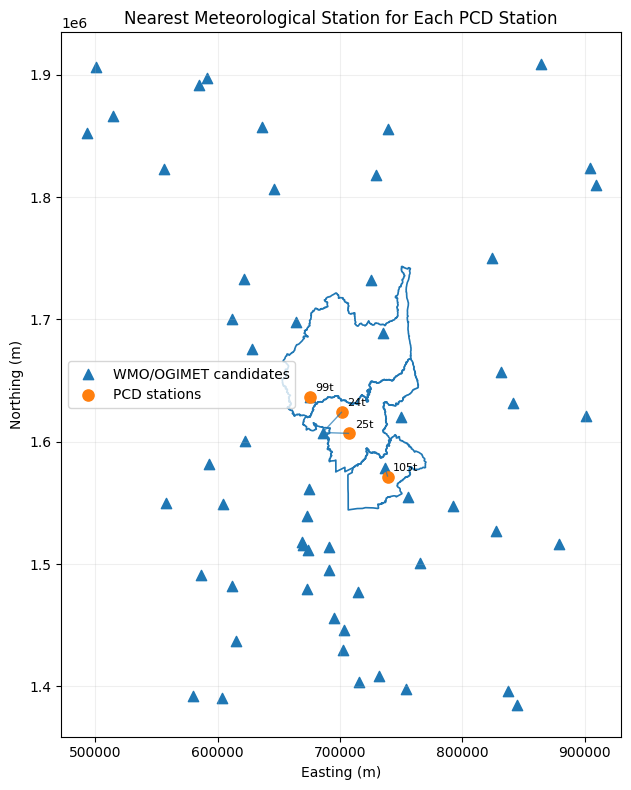

In [29]:
# CELL 29 — Plot PCD-WMO nearest-station connections

fig, ax = plt.subplots(
    figsize=(
        10,
        8,
    )
)

case_provinces.to_crs(
    CASE_PROJECTED_CRS
).boundary.plot(
    ax=ax,
    linewidth=1.2,
)

connection_lines.plot(
    ax=ax,
    linewidth=1.0,
    alpha=0.7,
)

candidate_wmo_utm.plot(
    ax=ax,
    marker="^",
    markersize=55,
    label="WMO/OGIMET candidates",
)

case_pcd_utm.plot(
    ax=ax,
    markersize=65,
    label="PCD stations",
)


for _, row in case_pcd_utm.iterrows():

    ax.annotate(
        str(
            row[
                "station_id"
            ]
        ),
        xy=(
            row.geometry.x,
            row.geometry.y,
        ),
        xytext=(
            4,
            4,
        ),
        textcoords="offset points",
        fontsize=8,
    )


ax.set_xlabel(
    "Easting (m)"
)

ax.set_ylabel(
    "Northing (m)"
)

ax.set_title(
    "Nearest Meteorological Station for Each PCD Station"
)

ax.legend()

ax.grid(
    alpha=0.2
)

fig.tight_layout()

PAIR_MAP = (
    FIGURE_DIR
    / "04_case_PCD_WMO_nearest_connections.png"
)

fig.savefig(
    PAIR_MAP,
    dpi=250,
    bbox_inches="tight",
)

plt.show()

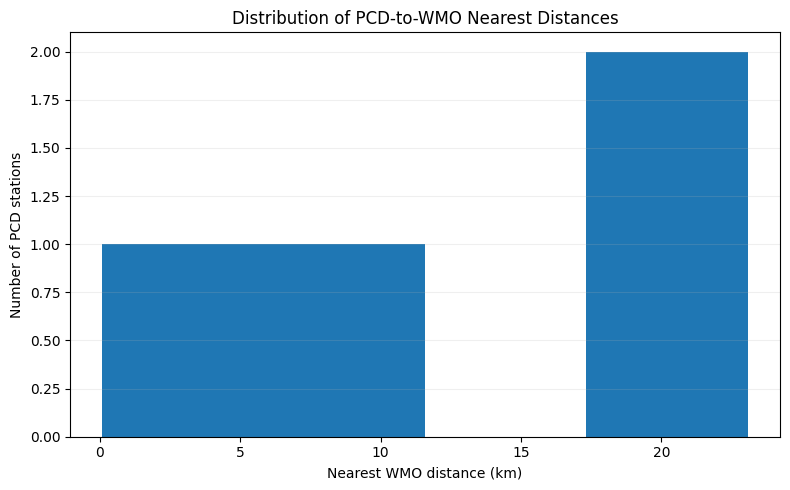

In [30]:
# CELL 30 — Nearest-distance distribution

fig, ax = plt.subplots(
    figsize=(
        8,
        5,
    )
)

ax.hist(
    nearest_projected[
        "distance_km_geodesic"
    ].dropna(),
    bins=min(
        12,
        max(
            4,
            len(
                nearest_projected
            ),
        ),
    ),
)

ax.set_xlabel(
    "Nearest WMO distance (km)"
)

ax.set_ylabel(
    "Number of PCD stations"
)

ax.set_title(
    "Distribution of PCD-to-WMO Nearest Distances"
)

ax.grid(
    axis="y",
    alpha=0.2,
)

fig.tight_layout()

DISTANCE_HIST = (
    FIGURE_DIR
    / "04_case_nearest_WMO_distance_histogram.png"
)

fig.savefig(
    DISTANCE_HIST,
    dpi=250,
    bbox_inches="tight",
)

plt.show()

# 4.15 One WMO Station May Serve Several PCD Stations

Nearest matching ไม่ได้เป็น one-to-one เสมอไป

อาจเกิด:

```text
PCD A ─┐
PCD B ─┼→ WMO X
PCD C ─┘
```

จึงควรถามว่า:

> meteorological network มีความหนาแน่นเพียงพอหรือไม่?

In [31]:
# CELL 31 — WMO usage by nearest PCD pairing

wmo_usage = (
    nearest_projected
    .groupby(
        [
            "wmo_id",
            "met_station_name",
        ],
        dropna=False,
    )
    .agg(
        pcd_station_n=(
            "station_id",
            "nunique",
        ),

        mean_pair_distance_km=(
            "distance_km_geodesic",
            "mean",
        ),

        maximum_pair_distance_km=(
            "distance_km_geodesic",
            "max",
        ),
    )
    .reset_index()
    .sort_values(
        [
            "pcd_station_n",
            "mean_pair_distance_km",
        ],
        ascending=[
            False,
            True,
        ],
    )
)


display(
    wmo_usage
)

,wmo_id,met_station_name,pcd_station_n,mean_pair_distance_km,maximum_pair_distance_km
1,48415,Ayutthaya,2,22.395260,23.072906
2,48426,Lop Buri,1,0.083885,0.083885
0,48414,Nakhon Nayok,1,7.825981,7.825981


# 4.16 Nearest ≠ Representative

Distance เป็นเพียงเกณฑ์แรก

ตัวอย่าง:

```text
PCD station
อยู่ในเมือง/แอ่ง/เชิงเขา

nearest WMO station
อยู่สนามบิน/ที่สูง/คนละด้านภูเขา
```

แม้ห่างเพียง 15 km
สภาพอุตุนิยมวิทยาอาจต่างกันมาก

---

# ปัจจัยที่ควรตรวจ

```text
1. horizontal distance
2. elevation difference
3. terrain / mountain barrier
4. urban vs rural
5. coast vs inland
6. land cover
7. prevailing wind
8. station exposure
9. data completeness
10. observation variables available
```

ดังนั้น station matching table ควรถูกมองว่า:

> **candidate relationship**

ไม่ใช่ proof of representativeness

# คำถามเชิงวิจัย

ถ้า PM₂.₅ สูงที่ PCD station และ nearest WMO station รายงานลมอ่อน

เรายังไม่สามารถสรุปว่า:

> “ลมอ่อนทำให้ PM₂.₅ สูง”

โดยอัตโนมัติ

ต้องพิจารณา:

- emission
- fire
- regional transport
- boundary-layer stability
- humidity
- precipitation
- synoptic environment
- temporal sequence

และต้องตรวจว่า WMO station เป็นตัวแทนสภาพที่ PCD station ได้มากน้อยเพียงใด

# 4.17 Advanced Section — National Nearest WMO by Geodesic Distance

EPSG:32647 เหมาะกับกรณีศึกษา 3 จังหวัด

แต่ประเทศไทยครอบคลุมหลาย UTM zones

ดังนั้นเราไม่ควรใช้ UTM 47N เพียง CRS เดียวเพื่อคำนวณ nearest distance ของทุก station ทั่วประเทศ

สำหรับ national matching จะใช้:

```text
WGS84 longitude/latitude
        ↓
Geodesic distance
        ↓
nearest WMO
```

วิธีนี้หลีกเลี่ยงปัญหาการเลือก projected CRS เดียวสำหรับทั้งประเทศ

In [32]:
# CELL 32 — Prepare national station coordinates

pcd_national = (
    pcd
    .to_crs(
        4326
    )
    .copy()
)


pcd_national[
    "pcd_longitude"
] = (
    pcd_national.geometry.x
)

pcd_national[
    "pcd_latitude"
] = (
    pcd_national.geometry.y
)


met_national = (
    ogimet_for_matching
    .to_crs(
        4326
    )
    .copy()
)


met_national[
    "met_longitude"
] = (
    met_national.geometry.x
)

met_national[
    "met_latitude"
] = (
    met_national.geometry.y
)


met_national = (
    met_national[
        met_national[
            "wmo_id"
        ]
        .notna()
        &
        met_national[
            "met_longitude"
        ]
        .notna()
        &
        met_national[
            "met_latitude"
        ]
        .notna()
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


print(
    "PCD national stations:",
    len(
        pcd_national
    )
)

print(
    "WMO national stations:",
    len(
        met_national
    )
)

PCD national stations: 173
WMO national stations: 130


In [33]:
# CELL 33 — National geodesic nearest-neighbor matching

national_pair_rows = []


met_lons = (
    met_national[
        "met_longitude"
    ]
    .to_numpy(
        dtype=float
    )
)

met_lats = (
    met_national[
        "met_latitude"
    ]
    .to_numpy(
        dtype=float
    )
)


for _, pcd_row in pcd_national.iterrows():

    p_lon = float(
        pcd_row[
            "pcd_longitude"
        ]
    )

    p_lat = float(
        pcd_row[
            "pcd_latitude"
        ]
    )


    p_lon_array = np.full(
        len(
            met_national
        ),
        p_lon,
        dtype=float,
    )

    p_lat_array = np.full(
        len(
            met_national
        ),
        p_lat,
        dtype=float,
    )


    azimuths, _, distances_m = (
        GEOD.inv(
            p_lon_array,
            p_lat_array,
            met_lons,
            met_lats,
        )
    )


    nearest_position = int(
        np.nanargmin(
            distances_m
        )
    )


    met_row = (
        met_national.iloc[
            nearest_position
        ]
    )


    national_pair_rows.append({
        "station_id":
            pcd_row[
                "station_id"
            ],

        "pcd_station_name":
            pcd_row.get(
                "station_name_en",
                pd.NA,
            ),

        "pcd_province":
            pcd_row.get(
                "province_name_en",
                pd.NA,
            ),

        "pcd_longitude":
            p_lon,

        "pcd_latitude":
            p_lat,

        "wmo_id":
            met_row[
                "wmo_id"
            ],

        "met_station_name":
            met_row[
                "met_station_name"
            ],

        "met_longitude":
            met_row[
                "met_longitude"
            ],

        "met_latitude":
            met_row[
                "met_latitude"
            ],

        "met_elevation_m":
            met_row.get(
                "met_elevation_m",
                np.nan,
            ),

        "distance_km_geodesic":
            float(
                distances_m[
                    nearest_position
                ]
            )
            / 1000,

        "azimuth_to_wmo_deg":
            float(
                azimuths[
                    nearest_position
                ]
            ),
    })


national_nearest_wmo = pd.DataFrame(
    national_pair_rows
)


national_nearest_wmo[
    "distance_class"
] = pd.cut(
    national_nearest_wmo[
        "distance_km_geodesic"
    ],
    bins=distance_bins,
    labels=distance_labels,
    right=False,
)


display(
    national_nearest_wmo.head(
        20
    )
)

,station_id,pcd_station_name,pcd_province,pcd_longitude,pcd_latitude,wmo_id,met_station_name,met_longitude,met_latitude,met_elevation_m,distance_km_geodesic,azimuth_to_wmo_deg,distance_class
0,119t,Thara Public Park,Krabi,98.918049,8.050624,48563,Krabi,98.975278,8.103333,29,8.589099,47.253268,0-25 km
1,02t,Bansomdejchaopraya Rajabhat University,Bangkok,100.487662,13.732846,48455,Bangkok Metropolis,100.560000,13.726389,3,7.856561,95.208507,0-25 km
2,03t,Highway NO.3902 km.13 +600,Bangkok,100.414262,13.636514,48454,Bangkok Khlong Toey,100.568056,13.706667,3,18.359502,64.973671,0-25 km
3,05t,Thai Meteorological Department,Bangkok,100.605742,13.666183,48453,Bang Na Agromet,100.605833,13.666389,1,0.024830,23.450641,0-25 km
4,12t,Nonsi Witthaya School,Bangkok,100.547333,13.708067,48454,Bangkok Khlong Toey,100.568056,13.706667,3,2.246857,93.950482,0-25 km
5,50t,Chulalongkorn Hospital,Bangkok,100.536501,13.729852,48455,Bangkok Metropolis,100.560000,13.726389,3,2.570364,98.569875,0-25 km
6,52t,Thonburi Power Sub-Station,Bangkok,100.486568,13.727622,48455,Bangkok Metropolis,100.560000,13.726389,3,7.943599,90.975363,0-25 km
7,53t,Chokchai Police Station,Bangkok,100.593030,13.795425,48455,Bangkok Metropolis,100.560000,13.726389,3,8.431917,-154.932195,0-25 km
8,54t,National Housing Authority Dindaeng,Bangkok,100.550200,13.762517,48455,Bangkok Metropolis,100.560000,13.726389,3,4.135206,165.147644,0-25 km
9,59t,The Government Public Relations Department,Bangkok,100.540489,13.783185,48455,Bangkok Metropolis,100.560000,13.726389,3,6.628572,161.435777,0-25 km


In [34]:
# CELL 34 — National nearest-distance summary

national_distance_summary = (
    national_nearest_wmo[
        "distance_km_geodesic"
    ]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
        ]
    )
    .rename(
        "value"
    )
    .reset_index()
    .rename(
        columns={
            "index":
                "statistic"
        }
    )
)


display(
    national_distance_summary
)


display(
    national_nearest_wmo[
        "distance_class"
    ]
    .value_counts(
        dropna=False
    )
    .rename_axis(
        "distance_class"
    )
    .reset_index(
        name="pcd_station_n"
    )
)

,statistic,value
0,count,173.000000
1,mean,9.673977
2,std,10.744194
3,min,0.024830
4,25%,2.935726
5,50%,6.670076
6,75%,12.533270
7,90%,22.479473
8,95%,27.555257
9,max,86.142292


,distance_class,pcd_station_n
0,0-25 km,159
1,25-50 km,12
2,50-100 km,2
3,>100 km,0


# 4.18 Compare Two Matching Methods in the Case Study

สำหรับ 3 จังหวัด เรามี 2 วิธี:

```text
Method A
UTM 47N + sjoin_nearest()

Method B
National WGS84 + geodesic nearest
```

ถ้า candidate set และ projection เหมาะสม
nearest WMO ID ควรสอดคล้องกันเป็นส่วนใหญ่

ถ้าไม่ตรง ต้องตรวจ:

- candidate search extent
- station duplicates
- projection
- equal-distance ties
- coordinate quality

In [35]:
# CELL 35 — Compare case-study nearest IDs

case_projected_pairs = (
    nearest_projected[
        [
            "station_id",
            "wmo_id",
            "distance_km_geodesic",
        ]
    ]
    .rename(
        columns={
            "wmo_id":
                "wmo_id_projected_method",

            "distance_km_geodesic":
                "distance_km_case_method",
        }
    )
)


case_national_pairs = (
    national_nearest_wmo[
        [
            "station_id",
            "wmo_id",
            "distance_km_geodesic",
        ]
    ]
    .rename(
        columns={
            "wmo_id":
                "wmo_id_national_geodesic",

            "distance_km_geodesic":
                "distance_km_national_method",
        }
    )
)


case_method_comparison = (
    case_projected_pairs
    .merge(
        case_national_pairs,
        on="station_id",
        how="left",
        validate="one_to_one",
    )
)


case_method_comparison[
    "nearest_wmo_same"
] = (
    case_method_comparison[
        "wmo_id_projected_method"
    ]
    ==
    case_method_comparison[
        "wmo_id_national_geodesic"
    ]
)


display(
    case_method_comparison
)


print(
    "Same nearest WMO:",
    int(
        case_method_comparison[
            "nearest_wmo_same"
        ].sum()
    ),
    "/",
    len(
        case_method_comparison
    )
)

,station_id,wmo_id_projected_method,distance_km_case_method,wmo_id_national_geodesic,distance_km_national_method,nearest_wmo_same
0,105t,48414,7.825981,48414,7.825981,True
1,24t,48415,23.072906,48415,23.072906,True
2,25t,48415,21.717615,48415,21.717615,True
3,99t,48426,0.083885,48426,0.083885,True


Same nearest WMO: 4 / 4


# 4.19 Connect Station Matching Back to PM₂.₅

Notebook 02 มี:

```text
station_id
date
pm25_mean
```

Notebook 04 มี:

```text
station_id
nearest wmo_id
distance_km
```

จึงทำ attribute join:

```text
PM2.5 daily
       +
nearest-WMO table
       ↓
PM2.5 daily + meteorological station candidate
```

---

## สำคัญ

ตารางที่ได้ยัง **ไม่มี meteorological observations**

มันบอกเพียงว่า:

```text
PM2.5 observation ของ station นี้
สัมพันธ์กับ candidate WMO station ใด
```

การ merge:

```text
temperature
RH
wind
rainfall
```

จะทำได้เมื่อมี meteorological observation dataset ที่วันเวลาสอดคล้องกัน

In [36]:
# CELL 36 — Read Notebook 02 PM2.5 daily output

if (
    PM25_DAILY_FILE is None
    or not PM25_DAILY_FILE.exists()
):

    print(
        "PM2.5 daily file not found."
    )

    print(
        "Station-matching analyses remain valid, "
        "but PM2.5 bridge output will be skipped."
    )

    pm25_daily = pd.DataFrame()

else:

    pm25_daily = pd.read_csv(
        PM25_DAILY_FILE,
        dtype={
            "station_id":
                "string"
        },
        parse_dates=[
            "date"
        ],
    )


    pm25_daily[
        "station_id"
    ] = (
        pm25_daily[
            "station_id"
        ]
        .astype(
            "string"
        )
        .str.strip()
        .str.lower()
    )


    print(
        "PM2.5 daily rows:",
        len(
            pm25_daily
        )
    )

    print(
        "Stations:",
        pm25_daily[
            "station_id"
        ].nunique()
    )

PM2.5 daily rows: 70173
Stations: 105


In [37]:
# CELL 37 — Merge national nearest WMO metadata into PM2.5 daily data

if len(
    pm25_daily
) > 0:

    pair_fields = [
        "station_id",
        "wmo_id",
        "met_station_name",
        "met_longitude",
        "met_latitude",
        "met_elevation_m",
        "distance_km_geodesic",
        "azimuth_to_wmo_deg",
        "distance_class",
    ]


    pm25_with_wmo_candidate = (
        pm25_daily
        .merge(
            national_nearest_wmo[
                pair_fields
            ],
            on="station_id",
            how="left",
            validate="many_to_one",
        )
    )


    print(
        "Merged PM2.5 rows:",
        len(
            pm25_with_wmo_candidate
        )
    )

    print(
        "Rows with WMO candidate:",
        int(
            pm25_with_wmo_candidate[
                "wmo_id"
            ]
            .notna()
            .sum()
        )
    )


    display(
        pm25_with_wmo_candidate.head(
            10
        )
    )

else:

    pm25_with_wmo_candidate = (
        pd.DataFrame()
    )

Merged PM2.5 rows: 70173
Rows with WMO candidate: 68340


,station_id,date,pm25_mean,pm25_median,pm25_min,pm25_max,n_obs,station_name_th,station_name_en,province_name_en,...,year,month,wmo_id,met_station_name,met_longitude,met_latitude,met_elevation_m,distance_km_geodesic,azimuth_to_wmo_deg,distance_class
0,02t,2024-01-01,38.3,38.3,38.3,38.3,1,มหาวิทยาลัยราชภัฏบ้านสมเด็จเจ้าพระยา,Bansomdejchaopraya Rajabhat University,Bangkok,...,2024,1,48455,Bangkok Metropolis,100.56,13.726389,3.0,7.856561,95.208507,0-25 km
1,02t,2024-01-02,39.5,39.5,39.5,39.5,1,มหาวิทยาลัยราชภัฏบ้านสมเด็จเจ้าพระยา,Bansomdejchaopraya Rajabhat University,Bangkok,...,2024,1,48455,Bangkok Metropolis,100.56,13.726389,3.0,7.856561,95.208507,0-25 km
2,02t,2024-01-03,38.2,38.2,38.2,38.2,1,มหาวิทยาลัยราชภัฏบ้านสมเด็จเจ้าพระยา,Bansomdejchaopraya Rajabhat University,Bangkok,...,2024,1,48455,Bangkok Metropolis,100.56,13.726389,3.0,7.856561,95.208507,0-25 km
3,02t,2024-01-04,36.6,36.6,36.6,36.6,1,มหาวิทยาลัยราชภัฏบ้านสมเด็จเจ้าพระยา,Bansomdejchaopraya Rajabhat University,Bangkok,...,2024,1,48455,Bangkok Metropolis,100.56,13.726389,3.0,7.856561,95.208507,0-25 km
4,02t,2024-01-05,36.0,36.0,36.0,36.0,1,มหาวิทยาลัยราชภัฏบ้านสมเด็จเจ้าพระยา,Bansomdejchaopraya Rajabhat University,Bangkok,...,2024,1,48455,Bangkok Metropolis,100.56,13.726389,3.0,7.856561,95.208507,0-25 km
5,02t,2024-01-06,42.8,42.8,42.8,42.8,1,มหาวิทยาลัยราชภัฏบ้านสมเด็จเจ้าพระยา,Bansomdejchaopraya Rajabhat University,Bangkok,...,2024,1,48455,Bangkok Metropolis,100.56,13.726389,3.0,7.856561,95.208507,0-25 km
6,02t,2024-01-07,44.0,44.0,44.0,44.0,1,มหาวิทยาลัยราชภัฏบ้านสมเด็จเจ้าพระยา,Bansomdejchaopraya Rajabhat University,Bangkok,...,2024,1,48455,Bangkok Metropolis,100.56,13.726389,3.0,7.856561,95.208507,0-25 km
7,02t,2024-01-08,49.3,49.3,49.3,49.3,1,มหาวิทยาลัยราชภัฏบ้านสมเด็จเจ้าพระยา,Bansomdejchaopraya Rajabhat University,Bangkok,...,2024,1,48455,Bangkok Metropolis,100.56,13.726389,3.0,7.856561,95.208507,0-25 km
8,02t,2024-01-09,68.0,68.0,68.0,68.0,1,มหาวิทยาลัยราชภัฏบ้านสมเด็จเจ้าพระยา,Bansomdejchaopraya Rajabhat University,Bangkok,...,2024,1,48455,Bangkok Metropolis,100.56,13.726389,3.0,7.856561,95.208507,0-25 km
9,02t,2024-01-10,44.3,44.3,44.3,44.3,1,มหาวิทยาลัยราชภัฏบ้านสมเด็จเจ้าพระยา,Bansomdejchaopraya Rajabhat University,Bangkok,...,2024,1,48455,Bangkok Metropolis,100.56,13.726389,3.0,7.856561,95.208507,0-25 km


# 4.20 What This Table Can and Cannot Say

ตาราง:

```text
pm25_with_wmo_candidate
```

สามารถบอก:

```text
PM2.5 station A
nearest WMO station B
distance = X km
```

แต่ยังไม่สามารถบอก:

```text
wind at B caused PM2.5 at A
```

หรือ:

```text
temperature at B = temperature at A
```

โดยไม่มีการตรวจ representativeness

นี่เป็นหลักสำคัญมากสำหรับงาน publication

In [38]:
# CELL 38 — Build publication-style case station-pair table

case_pair_table = (
    nearest_projected[
        [
            c
            for c
            in [
                "station_id",
                "station_name_en",
                "sj_province_name_en",
                "sj_amphoe_name_en",
                "sj_tambon_name_en",
                "pcd_latitude",
                "pcd_longitude",
                "wmo_id",
                "met_station_name",
                "met_latitude",
                "met_longitude",
                "met_elevation_m",
                "distance_km_geodesic",
                "azimuth_to_wmo_deg",
                "distance_class",
                "distance_difference_pct",
            ]
            if c
            in nearest_projected.columns
        ]
    ]
    .copy()
)


case_pair_table = (
    case_pair_table
    .sort_values(
        [
            "sj_province_name_en",
            "station_id",
        ]
    )
    .reset_index(
        drop=True
    )
)


display(
    case_pair_table
)

,station_id,station_name_en,sj_province_name_en,sj_amphoe_name_en,sj_tambon_name_en,pcd_latitude,pcd_longitude,wmo_id,met_station_name,met_latitude,met_longitude,met_elevation_m,distance_km_geodesic,azimuth_to_wmo_deg,distance_class,distance_difference_pct
0,99t,Meteorological Station Lopburi,Lop Buri,Mueang Lop Buri,Thale Chup Son,14.800032,100.628548,48426,Lop Buri,14.799444,100.628056,10,0.083885,-140.805318,0-25 km,0.002018
1,105t,Nakhon Nayok Municipality Public Health Servic...,Nakhon Nayok,Mueang Nakhon Nayok,Nakhon Nayok,14.204220,101.215090,48414,Nakhon Nayok,14.271944,101.194167,24,7.825981,-16.767813,0-25 km,0.030002
2,24t,Na Phralan Police Station,Saraburi,Chaloem Phra Kiat,Na Phralan,14.685833,100.871996,48415,Ayutthaya,14.534444,100.724722,8,23.072906,-136.531509,0-25 km,0.006438
3,25t,Khao Noi Fire Station,Saraburi,Mueang Saraburi,Pak Phriao,14.526343,100.926047,48415,Ayutthaya,14.534444,100.724722,8,21.717615,-87.609236,0-25 km,0.007903


# 4.21 Save Outputs

Notebook นี้จะสร้าง:

```text
04_PCD_spatial_join_admin.csv
04_spatial_join_validation.csv
04_admin_mismatches.csv

04_case_PCD_WMO_nearest.csv
04_case_PCD_WMO_top3_candidates.csv
04_case_candidate_distance_comparison.csv
04_case_matching_method_comparison.csv
04_WMO_usage_case_study.csv

04_national_PCD_WMO_nearest_geodesic.csv
04_national_nearest_distance_summary.csv

04_PM25_daily_with_nearest_WMO_candidate.csv.gz
```

และ:

```text
04_case_station_matching.gpkg
```

ที่มี:

```text
case_provinces
case_pcd
candidate_wmo
nearest_connection_lines
```

In [39]:
# CELL 39 — Save CSV outputs

spatial_join_qc = pd.DataFrame([
    qc_province,
    qc_amphoe,
    qc_tambon,
])


CSV_OUTPUTS = {
    "04_PCD_spatial_join_admin.csv":
        pcd_admin_from_geometry.drop(
            columns="geometry",
            errors="ignore",
        ),

    "04_spatial_join_QC.csv":
        spatial_join_qc,

    "04_spatial_join_validation.csv":
        admin_validation,

    "04_admin_mismatches.csv":
        admin_mismatches,

    "04_case_PCD_WMO_nearest.csv":
        case_pair_table,

    "04_case_PCD_WMO_top3_candidates.csv":
        top3_candidates,

    "04_case_candidate_distance_comparison.csv":
        candidate_distance_pivot,

    "04_case_matching_method_comparison.csv":
        case_method_comparison,

    "04_WMO_usage_case_study.csv":
        wmo_usage,

    "04_national_PCD_WMO_nearest_geodesic.csv":
        national_nearest_wmo,

    "04_national_nearest_distance_summary.csv":
        national_distance_summary,
}


for filename, table in CSV_OUTPUTS.items():

    path = (
        OUTPUT_DIR
        / filename
    )

    table.to_csv(
        path,
        index=False,
        encoding="utf-8-sig",
    )

    print(
        "Saved:",
        filename
    )

Saved: 04_PCD_spatial_join_admin.csv
Saved: 04_spatial_join_QC.csv
Saved: 04_spatial_join_validation.csv
Saved: 04_admin_mismatches.csv
Saved: 04_case_PCD_WMO_nearest.csv
Saved: 04_case_PCD_WMO_top3_candidates.csv
Saved: 04_case_candidate_distance_comparison.csv
Saved: 04_case_matching_method_comparison.csv
Saved: 04_WMO_usage_case_study.csv
Saved: 04_national_PCD_WMO_nearest_geodesic.csv
Saved: 04_national_nearest_distance_summary.csv


In [40]:
# CELL 40 — Save PM2.5 bridge table

PM25_WMO_OUTPUT = (
    OUTPUT_DIR
    / "04_PM25_daily_with_nearest_WMO_candidate.csv.gz"
)


if len(
    pm25_with_wmo_candidate
) > 0:

    pm25_with_wmo_candidate.to_csv(
        PM25_WMO_OUTPUT,
        index=False,
        compression="gzip",
    )

    print(
        "Saved:",
        PM25_WMO_OUTPUT
    )

else:

    print(
        "PM2.5 bridge table was not created "
        "because Notebook 02 output was unavailable."
    )

Saved: /content/drive/MyDrive/Teaching_PCD_Environmental_GIS/02_output/Notebook_04/04_PM25_daily_with_nearest_WMO_candidate.csv.gz


In [41]:
# CELL 41 — Save case-study GeoPackage

MATCHING_GPKG = (
    OUTPUT_DIR
    / "04_case_station_matching.gpkg"
)


if MATCHING_GPKG.exists():

    MATCHING_GPKG.unlink()


case_provinces.to_file(
    MATCHING_GPKG,
    layer="case_provinces",
    driver="GPKG",
)


case_pcd.to_file(
    MATCHING_GPKG,
    layer="case_pcd",
    driver="GPKG",
    mode="a",
)


candidate_wmo.to_file(
    MATCHING_GPKG,
    layer="candidate_wmo",
    driver="GPKG",
    mode="a",
)


connection_lines.to_file(
    MATCHING_GPKG,
    layer="nearest_connection_lines",
    driver="GPKG",
    mode="a",
)


print(
    "Saved:",
    MATCHING_GPKG
)

Saved: /content/drive/MyDrive/Teaching_PCD_Environmental_GIS/02_output/Notebook_04/04_case_station_matching.gpkg


# 4.22 Final Notebook Checkpoint

Notebook 04 ถือว่าพร้อมเมื่อ:

```text
Spatial join province/amphoe/tambon completed
case PCD stations > 0
regional WMO candidates > 0
UTM nearest matching completed
geodesic validation completed
top-3 candidates completed
national geodesic matching completed
outputs saved
```

ถ้ามี administrative mismatch:

```text
ไม่จำเป็นต้องถือว่า Notebook ล้มเหลว
```

แต่ต้องรายงานและตรวจสอบ

In [42]:
# CELL 42 — Final Notebook 04 checkpoint

spatial_join_completed = (
    len(
        pcd_admin_from_geometry
    )
    == len(
        pcd
    )
)


case_nearest_complete = (
    len(
        nearest_projected
    )
    == len(
        case_pcd
    )
    and nearest_projected[
        "wmo_id"
    ]
    .notna()
    .all()
)


geodesic_complete = (
    nearest_projected[
        "distance_km_geodesic"
    ]
    .notna()
    .all()
)


top3_complete = (
    len(
        top3_candidates
    )
    >= len(
        case_pcd
    )
)


national_complete = (
    len(
        national_nearest_wmo
    )
    == len(
        pcd
    )
    and national_nearest_wmo[
        "wmo_id"
    ]
    .notna()
    .all()
)


output_complete = all(
    (
        OUTPUT_DIR
        / filename
    ).exists()
    for filename
    in [
        "04_PCD_spatial_join_admin.csv",
        "04_case_PCD_WMO_nearest.csv",
        "04_case_PCD_WMO_top3_candidates.csv",
        "04_national_PCD_WMO_nearest_geodesic.csv",
    ]
)


final_checks = pd.DataFrame([
    {
        "check":
            "Spatial join completed",

        "status":
            (
                "PASS"
                if spatial_join_completed
                else "FAIL"
            ),

        "detail":
            (
                f"{len(pcd_admin_from_geometry)}"
                f"/{len(pcd)}"
            ),
    },

    {
        "check":
            "Case-study PCD stations",

        "status":
            (
                "PASS"
                if len(
                    case_pcd
                ) > 0
                else "FAIL"
            ),

        "detail":
            str(
                len(
                    case_pcd
                )
            ),
    },

    {
        "check":
            "Regional WMO candidates",

        "status":
            (
                "PASS"
                if len(
                    candidate_wmo
                ) > 0
                else "FAIL"
            ),

        "detail":
            str(
                len(
                    candidate_wmo
                )
            ),
    },

    {
        "check":
            "Nearest matching complete",

        "status":
            (
                "PASS"
                if case_nearest_complete
                else "FAIL"
            ),

        "detail":
            str(
                len(
                    nearest_projected
                )
            ),
    },

    {
        "check":
            "Geodesic validation",

        "status":
            (
                "PASS"
                if geodesic_complete
                else "FAIL"
            ),

        "detail":
            (
                f"median difference = "
                f"{nearest_projected['distance_difference_pct'].median():.4f}%"
            ),
    },

    {
        "check":
            "Top-3 candidates",

        "status":
            (
                "PASS"
                if top3_complete
                else "FAIL"
            ),

        "detail":
            str(
                len(
                    top3_candidates
                )
            ),
    },

    {
        "check":
            "National geodesic matching",

        "status":
            (
                "PASS"
                if national_complete
                else "FAIL"
            ),

        "detail":
            (
                f"{len(national_nearest_wmo)}"
                f"/{len(pcd)}"
            ),
    },

    {
        "check":
            "Core outputs saved",

        "status":
            (
                "PASS"
                if output_complete
                else "FAIL"
            ),

        "detail":
            str(
                OUTPUT_DIR
            ),
    },

    {
        "check":
            "Administrative mismatches",

        "status":
            (
                "PASS"
                if len(
                    admin_mismatches
                ) == 0
                else "REVIEW"
            ),

        "detail":
            str(
                len(
                    admin_mismatches
                )
            ),
    },
])


display(
    final_checks
)


hard_fail = (
    final_checks[
        "status"
    ]
    .eq(
        "FAIL"
    )
    .any()
)


if not hard_fail:

    print(
        "\n========================================"
    )

    print(
        "NOTEBOOK 04 SPATIAL MATCHING READY"
    )

    print(
        "========================================"
    )

else:

    print(
        "\nCHECK NOTEBOOK 04 RESULTS "
        "BEFORE CONTINUING"
    )

,check,status,detail
0,Spatial join completed,PASS,173/173
1,Case-study PCD stations,PASS,4
2,Regional WMO candidates,PASS,58
3,Nearest matching complete,PASS,4
4,Geodesic validation,PASS,median difference = 0.0072%
5,Top-3 candidates,PASS,12
6,National geodesic matching,PASS,173/173
7,Core outputs saved,PASS,/content/drive/MyDrive/Teaching_PCD_Environmen...
8,Administrative mismatches,PASS,0



NOTEBOOK 04 SPATIAL MATCHING READY


# แบบฝึกหัดท้ายบท

## Exercise 1 — Attribute Join vs Spatial Join

อธิบายว่า:

```text
pd.merge()
```

ต่างจาก:

```text
gpd.sjoin()
```

อย่างไร

ยกตัวอย่างสิ่งแวดล้อมอย่างละ 2 ตัวอย่าง

---

## Exercise 2 — Province from Geometry

เลือก PCD station 5 แห่ง

รายงาน:

```text
station_id
original province
spatial-join province
match?
```

ถ้าไม่ตรง ให้อธิบายสาเหตุที่เป็นไปได้อย่างน้อย 3 ข้อ

---

## Exercise 3 — Spatial Predicate

อธิบาย:

```text
within
intersects
```

ถ้า station อยู่พอดีบนขอบเขตจังหวัด ผลอาจต่างกันอย่างไร?

---

## Exercise 4 — Nearest WMO

เลือก PCD station 1 แห่ง

รายงาน top-3 WMO:

```text
rank
WMO ID
station name
distance km
azimuth
```

แล้วตอบ:

> nearest station เหนือกว่า rank 2 อย่างชัดเจนหรือไม่?

ใช้:

```text
rank2_minus_rank1_km
```

ประกอบคำตอบ

---

## Exercise 5 — Projection vs Geodesic

เปรียบเทียบ:

```text
distance_km_projected
distance_km_geodesic
```

สำหรับทุก PCD station ใน 3 จังหวัด

หาค่า:

```text
mean absolute difference
maximum difference
percentage difference
```

อภิปรายว่า EPSG:32647 เหมาะกับกรณีศึกษานี้หรือไม่

---

## Exercise 6 — Monitoring Network Coverage

สร้างตารางจำนวน PCD stations ในแต่ละ distance class:

```text
0–25 km
25–50 km
50–100 km
>100 km
```

จากนั้นอภิปรายว่า:

> ความหนาแน่นของ WMO network อาจมีผลต่อการวิเคราะห์ PM₂.₅ กับอุตุนิยมวิทยาอย่างไร?

---

## Exercise 7 — Shared Meteorological Station

หาว่า WMO station ใดถูกเลือกเป็น nearest station ของ PCD มากที่สุด

ตอบ:

1. มีกี่ PCD stations?
2. ระยะทางเฉลี่ยเท่าไร?
3. ระยะทางสูงสุดเท่าไร?
4. การใช้ WMO station เดียวแทนหลาย PCD stations มีข้อจำกัดอะไร?

---

## Exercise 8 — Nearest ≠ Representative

เลือก PCD–WMO pair 1 คู่

เสนอข้อมูลเพิ่มเติมอย่างน้อย 5 ชนิดที่ควรตรวจ ก่อนสรุปว่า WMO station นั้น represent PCD station ได้ดี

---

## Exercise 9 — National vs Regional Matching

ใน 3 จังหวัด เปรียบเทียบ:

```text
UTM nearest
vs
national geodesic nearest
```

ถ้า WMO ID ไม่ตรงกัน ให้ตรวจและอธิบายสาเหตุ

---

## Exercise 10 — PM₂.₅ Bridge

เลือก PM₂.₅ station 1 แห่ง

แสดง:

```text
date
pm25_mean
nearest_wmo
distance_km
```

10 วันแรก

แล้วตอบ:

> ตารางนี้มีข้อมูลอุตุนิยมวิทยาจริงหรือยัง?

คำตอบที่ถูกต้องคือ:

```text
ยังไม่มี
```

เพราะเราเพิ่มเพียง meteorological-station relationship

# Common Mistakes

## Mistake 1 — ใช้ `pd.merge()` เพื่อถามว่า Point อยู่ Polygon ใด

ถ้าไม่มี administrative key:

```text
ต้องใช้ spatial relationship
```

---

## Mistake 2 — ใช้ distance ใน EPSG:4326 แล้วเรียกว่า km

ผิด

ต้อง:

```text
projected CRS
หรือ
geodesic distance
```

---

## Mistake 3 — ใช้ EPSG:32647 กับทุกสถานีทั่วประเทศไทยโดยไม่พิจารณาพื้นที่

UTM zone 47N เหมาะกับ case study นี้

แต่ national matching ควรใช้ projection strategy ที่เหมาะสม หรือ geodesic distance

---

## Mistake 4 — Nearest station = Representative station

ไม่จริงเสมอไป

Distance ไม่ได้บอก:

```text
terrain
elevation
urbanization
coastal influence
wind exposure
```

---

## Mistake 5 — เส้นเชื่อม PCD–WMO = ทิศทางลม

ไม่ใช่

เส้นนี้เป็นเพียง geometry connection

---

## Mistake 6 — Merge WMO ID แล้วถือว่ามี meteorological observations แล้ว

ยังไม่ใช่

ต้องมี:

```text
meteorological time series
+
date/time matching
```

อีกขั้น

# สิ่งที่ต้องจำจาก Notebook 04

## Spatial Join

```text
Point + Polygon
→ administrative relationship
```

## Nearest Neighbor

```text
Point + Point
→ distance relationship
```

## Metric Analysis

```text
Case study
→ EPSG:32647

National
→ geodesic distance
```

## Scientific Interpretation

```text
Nearest
≠
Representative
```

และ:

```text
Station matching
≠
Meteorological data integration
```

# Notebook ต่อไป

## Notebook 05 — Spatiotemporal PM₂.₅ Analysis

ชื่อที่แนะนำ:

```text
05_spatiotemporal_airquality_analysis.ipynb
```

จะรวม:

```text
PM2.5
+
Station geometry
+
Province
+
Time
```

เพื่อวิเคราะห์:

```text
2021–2025 annual maps
monthly variation
dry vs wet season
three-province comparison
station completeness
high-PM episode maps
consistent map classification
monitoring-network limitations
```

และจะใช้ผลจาก Notebook 04:

```text
nearest WMO station
distance
```

เป็น metadata ประกอบการวางแผน integration กับข้อมูลอุตุนิยมวิทยาต่อไป